In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

df = pd.read_csv("/Users/deniskorac/holiday_itinerary_repo/data/processed/pois_clean.csv")

df.head(1)

,uuid,uri,label,poi_kind,categories,estimated_duration_min,description,latitude,longitude,city,postal_code,department,region,phone,website,last_update
0,00294965-4322-3ff6-b452-fce439e44af3,https://data.datatourisme.fr/13/ca7cda3e-ce31-...,InterContinental Lyon-Hotel Dieu,lodging,"['Accommodation', 'FoodEstablishment', 'HotelT...",45,Rendez-vous sous le dôme ! Au cœur du Grand Hô...,45.758533,4.836925,Lyon 2e Arrondissement,69002,Rhône,Auvergne-Rhône-Alpes,+33 4 26 99 23 23,http://lyon.intercontinental.com/,2026-08-31 00:00:00+00:00


In [20]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2153 entries, 0 to 2152
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   uuid                    2153 non-null   str    
 1   uri                     2153 non-null   str    
 2   label                   2153 non-null   str    
 3   poi_kind                2153 non-null   str    
 4   categories              2153 non-null   str    
 5   estimated_duration_min  2153 non-null   int64  
 6   description             2089 non-null   str    
 7   latitude                2153 non-null   float64
 8   longitude               2153 non-null   float64
 9   city                    2153 non-null   str    
 10  postal_code             2153 non-null   int64  
 11  department              2153 non-null   str    
 12  region                  2153 non-null   str    
 13  phone                   2078 non-null   str    
 14  website                 1599 non-null   str    
 15

In [21]:
X = df[["latitude", "longitude"]]

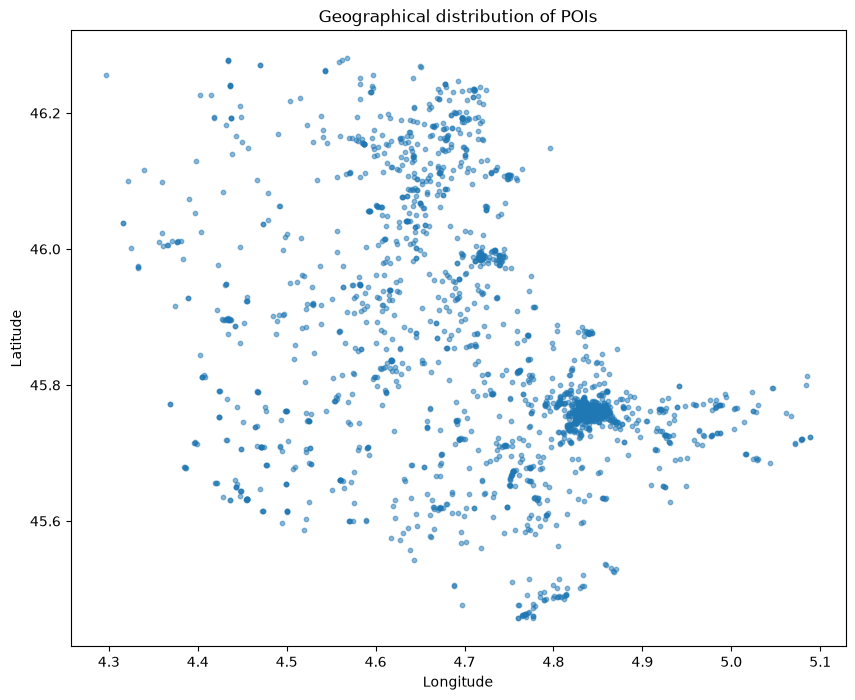

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.5,
    s=10
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical distribution of POIs")

plt.show()

In [23]:
inertias = []

K = range(2, 16)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    model.fit(X)

    inertias.append(model.inertia_)

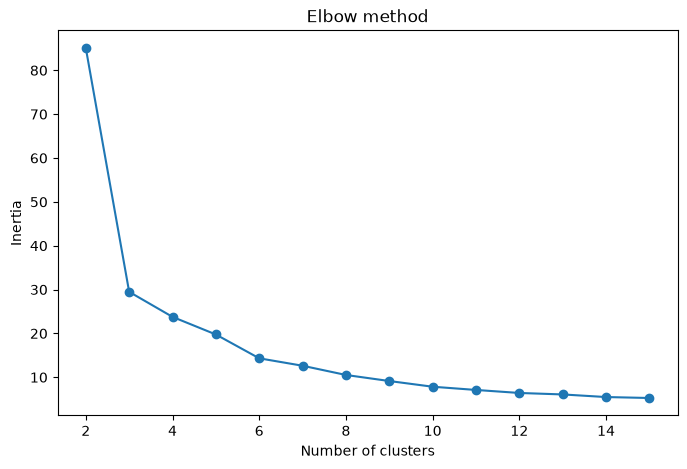

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertias, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method")

plt.show()


In [25]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init="auto"
)

df["cluster_id"] = kmeans.fit_predict(X)


df["cluster_id"].value_counts().sort_index()

cluster_id
0     339
1     244
2     328
3    1127
4     115
Name: count, dtype: int64

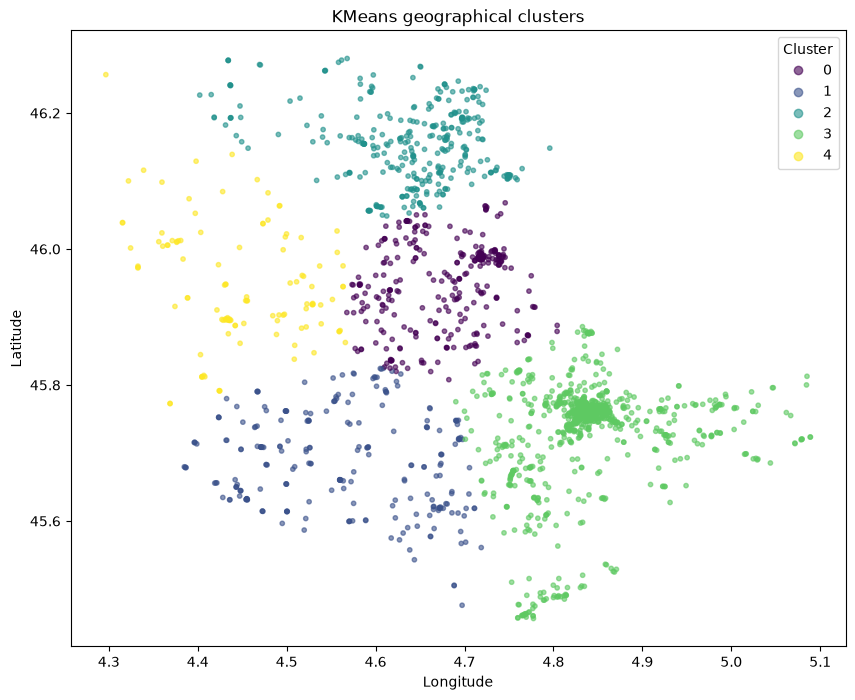

In [26]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["cluster_id"],
    s=10,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KMeans geographical clusters")

handles, labels = scatter.legend_elements()

plt.legend(
    handles,
    labels,
    title="Cluster"
)

plt.show()

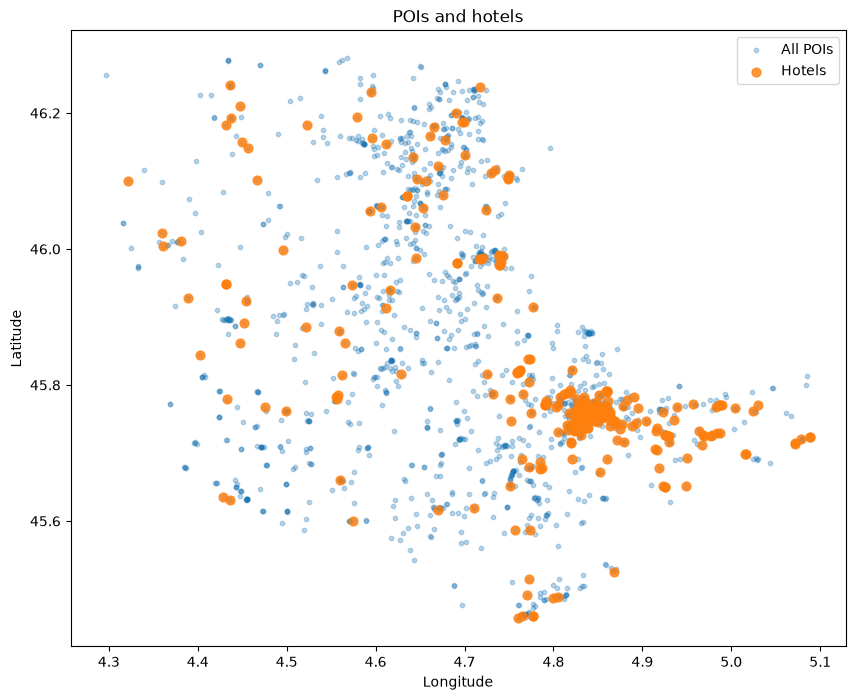

In [29]:
hotels = df[df["poi_kind"] == "lodging"]

plt.figure(figsize=(10, 8))

# All POIs
plt.scatter(
    df["longitude"],
    df["latitude"],
    s=10,
    alpha=0.3,
    label="All POIs"
)

# Hotels
plt.scatter(
    hotels["longitude"],
    hotels["latitude"],
    s=40,
    alpha=0.8,
    label="Hotels"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("POIs and hotels")

plt.legend()
plt.show()

In [ ]:
df.to_csv(
    "/Users/deniskorac/holiday_itinerary_repo/data/processed/pois_clustered.csv",
    index=False
)

df.to_json(
    "/Users/deniskorac/holiday_itinerary_repo/data/processed/pois_clustered.json",
    orient="records",
    force_ascii=False,
    indent=2,
    date_format="iso"
)